In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("RetailPulse Day 1 EDA")
print("Environment is ready!")

RetailPulse Day 1 EDA
Environment is ready!


In [2]:
# Load the RetailPulse dataset

file_path = "../data/raw/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 541909
Columns: 8


In [3]:
# Inspect the first 10 rows
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [4]:
# Check column names
print("Columns:")
print(df.columns.tolist())

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [5]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [7]:
# Missing-value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing-value percentage:")
print(missing_percentage.round(2))

Missing-value percentage:
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


In [8]:
# Descriptive statistics for numerical columns

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [9]:
# Basic statistics for sales-related columns

print("Quantity statistics:")
print(df["Quantity"].describe())

print("\nUnit Price statistics:")
print(df["UnitPrice"].describe())

Quantity statistics:
count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

Unit Price statistics:
count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64


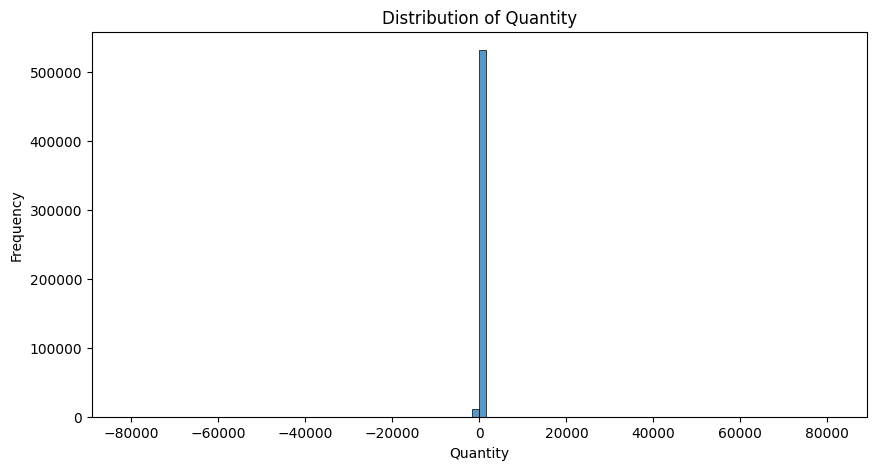

In [10]:
# Distribution of Quantity

plt.figure(figsize=(10, 5))
sns.histplot(df["Quantity"], bins=100)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

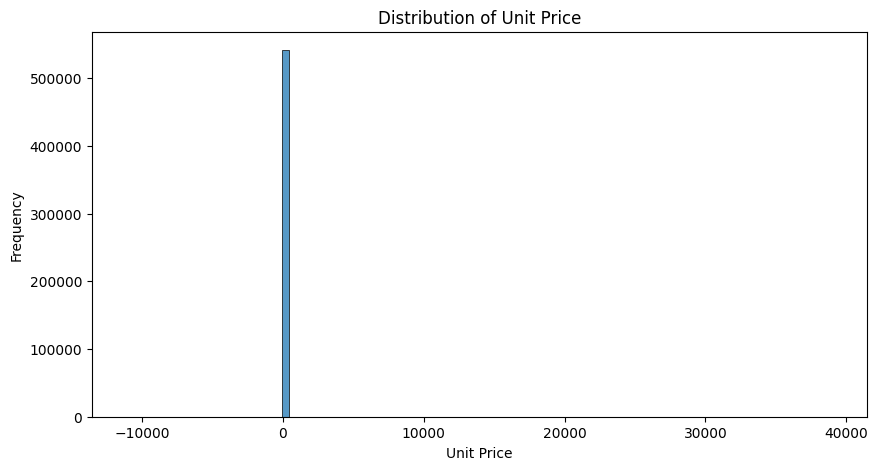

In [11]:
# Distribution of Unit Price

plt.figure(figsize=(10, 5))
sns.histplot(df["UnitPrice"], bins=100)
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

In [12]:
# Correlation analysis

numeric_columns = ["Quantity", "UnitPrice", "CustomerID"]

correlation_matrix = df[numeric_columns].corr()

print(correlation_matrix)

            Quantity  UnitPrice  CustomerID
Quantity    1.000000  -0.001235    -0.00360
UnitPrice  -0.001235   1.000000    -0.00456
CustomerID -0.003600  -0.004560     1.00000


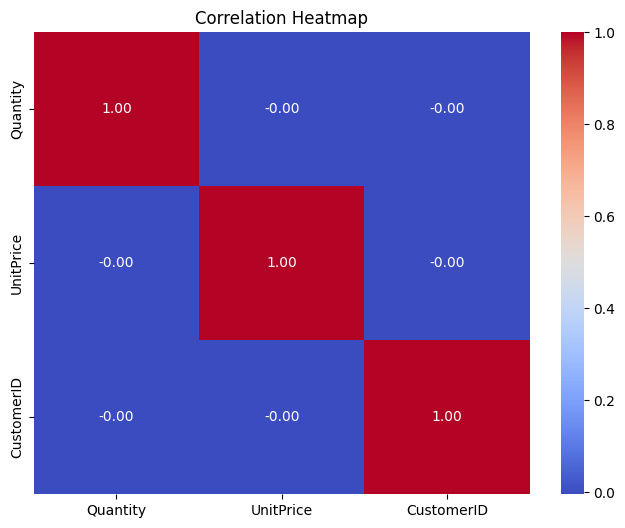

In [13]:
# Correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [14]:
# Calculate total revenue for each transaction

df["TotalRevenue"] = df["Quantity"] * df["UnitPrice"]

print("Total Revenue statistics:")
print(df["TotalRevenue"].describe())

Total Revenue statistics:
count    541909.000000
mean         17.987795
std         378.810824
min     -168469.600000
25%           3.400000
50%           9.750000
75%          17.400000
max      168469.600000
Name: TotalRevenue, dtype: float64


In [15]:
# Top 10 countries by total revenue

country_revenue = (
    df.groupby("Country")["TotalRevenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_revenue

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: TotalRevenue, dtype: float64

In [17]:
# Top 10 countries by total revenue

country_revenue = (
    df.groupby("Country")["TotalRevenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_revenue

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: TotalRevenue, dtype: float64

In [18]:
# Top 10 countries by total revenue

country_revenue = (
    df.groupby("Country")["TotalRevenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_revenue

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: TotalRevenue, dtype: float64

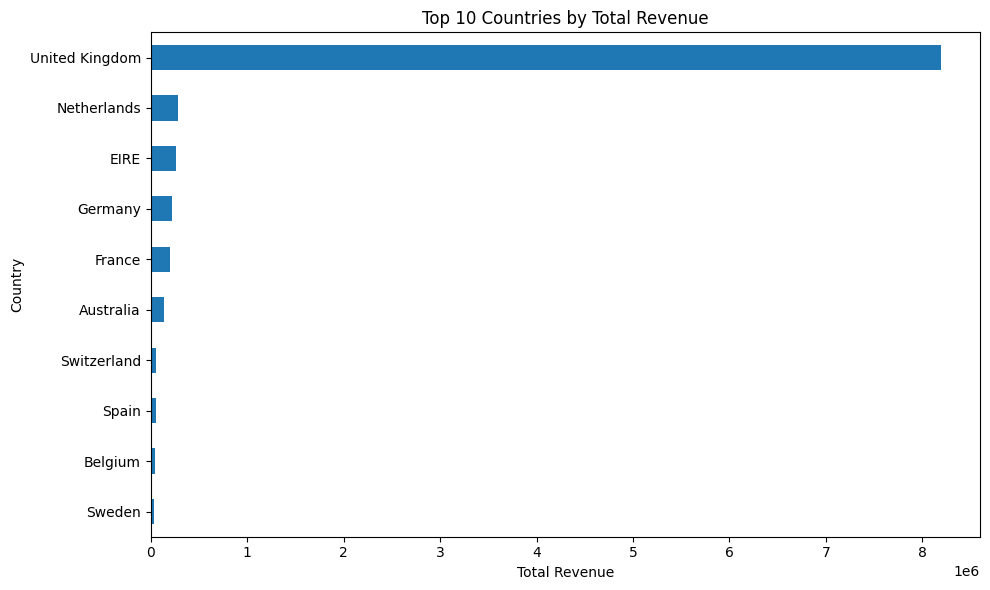

In [19]:
# Top 10 countries by total revenue

plt.figure(figsize=(10, 6))

country_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [20]:
# Monthly revenue trend

df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

monthly_revenue = (
    df.groupby("InvoiceMonth")["TotalRevenue"]
      .sum()
)

monthly_revenue

InvoiceMonth
2010-12     748957.020
2011-01     560000.260
2011-02     498062.650
2011-03     683267.080
2011-04     493207.121
2011-05     723333.510
2011-06     691123.120
2011-07     681300.111
2011-08     682680.510
2011-09    1019687.622
2011-10    1070704.670
2011-11    1461756.250
2011-12     433668.010
Freq: M, Name: TotalRevenue, dtype: float64

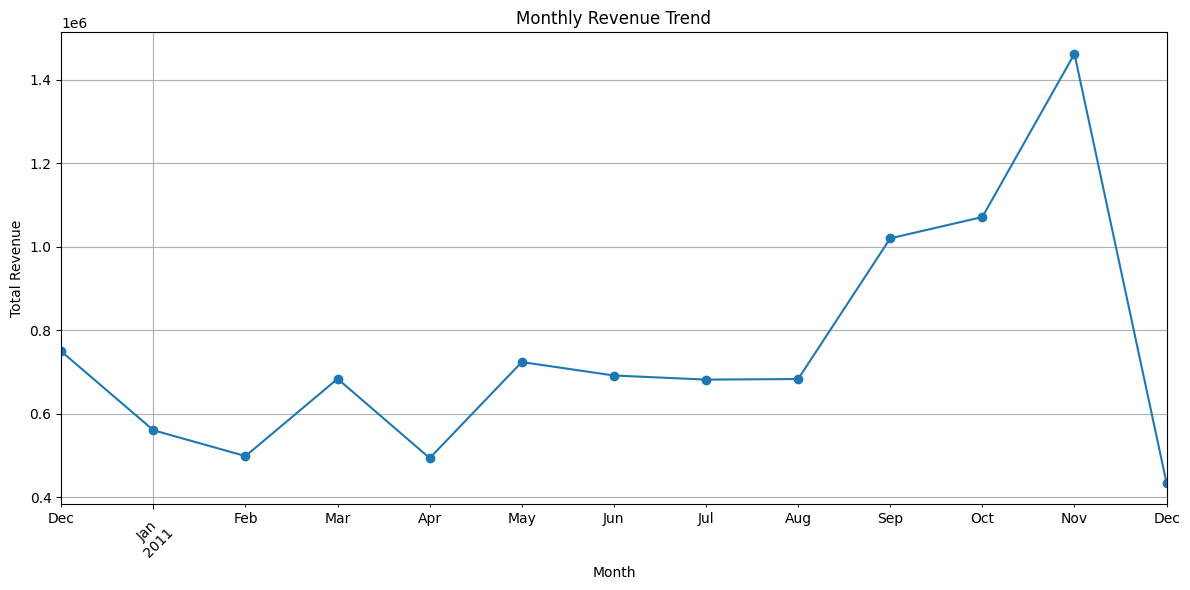

In [21]:
# Plot monthly revenue

plt.figure(figsize=(12, 6))

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Day 1 EDA Summary

## Dataset Overview

The RetailPulse project uses the UCI Online Retail dataset containing 541,909 transaction records and 8 columns.

## Key Findings

### 1. Missing Values
- Description has 1,454 missing values (0.27%).
- CustomerID has 135,080 missing values (24.93%).
- Other columns do not contain missing values.

### 2. Data Quality
- Quantity contains negative and very large values.
- UnitPrice contains negative and extreme values.
- These values require investigation during the data-cleaning stage.

### 3. Correlation
The correlation analysis showed very weak linear relationships between Quantity, UnitPrice, and CustomerID in the raw dataset.

### 4. Geographic Revenue
The United Kingdom accounts for the largest share of raw transaction revenue in the dataset, followed by the Netherlands, EIRE, Germany, and France.

### 5. Monthly Revenue
Monthly revenue shows considerable variation during the observation period, with a strong increase during September-November 2011.

December 2011 should be interpreted carefully because the dataset ends on 9 December 2011, making it a partial month.

## Day 1 Conclusion

The initial EDA identified missing customer information, extreme values, negative transactions, revenue differences across countries, and monthly revenue variation. These findings will guide the data-cleaning and feature-engineering work in the next stage.

In [22]:
# Day 2 - Inspect data quality issues

print("Total rows:", len(df))

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nNegative Quantity:")
print((df["Quantity"] < 0).sum())

print("\nZero Quantity:")
print((df["Quantity"] == 0).sum())

print("\nZero or negative UnitPrice:")
print((df["UnitPrice"] <= 0).sum())

print("\nMissing CustomerID:")
print(df["CustomerID"].isna().sum())

print("\nCancellation invoices:")
print(df["InvoiceNo"].astype(str).str.startswith("C").sum())

Total rows: 541909

Duplicate rows:
5268

Negative Quantity:
10624

Zero Quantity:
0

Zero or negative UnitPrice:
2517

Missing CustomerID:
135080

Cancellation invoices:
9288


In [23]:
# Day 2 - Clean the transaction data

df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove rows without CustomerID
df_clean = df_clean.dropna(subset=["CustomerID"])

# Remove cancellation invoices
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

# Keep only positive quantities
df_clean = df_clean[df_clean["Quantity"] > 0]

# Keep only positive unit prices
df_clean = df_clean[df_clean["UnitPrice"] > 0]

# Calculate revenue
df_clean["TotalRevenue"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 541909
Cleaned rows: 392692
Rows removed: 149217


In [24]:
# Verify the cleaned dataset

print("Missing CustomerID:", df_clean["CustomerID"].isna().sum())
print("Negative Quantity:", (df_clean["Quantity"] < 0).sum())
print("Invalid UnitPrice:", (df_clean["UnitPrice"] <= 0).sum())
print("Cancellation invoices:",
      df_clean["InvoiceNo"].astype(str).str.startswith("C").sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Missing CustomerID: 0
Negative Quantity: 0
Invalid UnitPrice: 0
Cancellation invoices: 0
Duplicate rows: 0


In [25]:
# Save cleaned dataset

output_path = "../data/processed/retail_clean.csv"

df_clean.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")
print("File:", output_path)

Cleaned dataset saved successfully!
File: ../data/processed/retail_clean.csv


In [26]:
# Day 2 - RFM Feature Engineering

# Set the reference date as one day after the last transaction
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df_clean.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalRevenue", "sum")
    )
    .reset_index()
)

print("Number of customers:", len(rfm))
print("\nRFM dataset:")
print(rfm.head())

Number of customers: 4338

RFM dataset:
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40


In [27]:
# RFM descriptive statistics

print("RFM Statistics:")
print(rfm[["Recency", "Frequency", "Monetary"]].describe())

RFM Statistics:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000


In [28]:
# Check for invalid RFM values

print("Negative Recency:", (rfm["Recency"] < 0).sum())
print("Zero/negative Frequency:", (rfm["Frequency"] <= 0).sum())
print("Zero/negative Monetary:", (rfm["Monetary"] <= 0).sum())
print("Missing RFM values:")
print(rfm[["Recency", "Frequency", "Monetary"]].isna().sum())

Negative Recency: 0
Zero/negative Frequency: 0
Zero/negative Monetary: 0
Missing RFM values:
Recency      0
Frequency    0
Monetary     0
dtype: int64


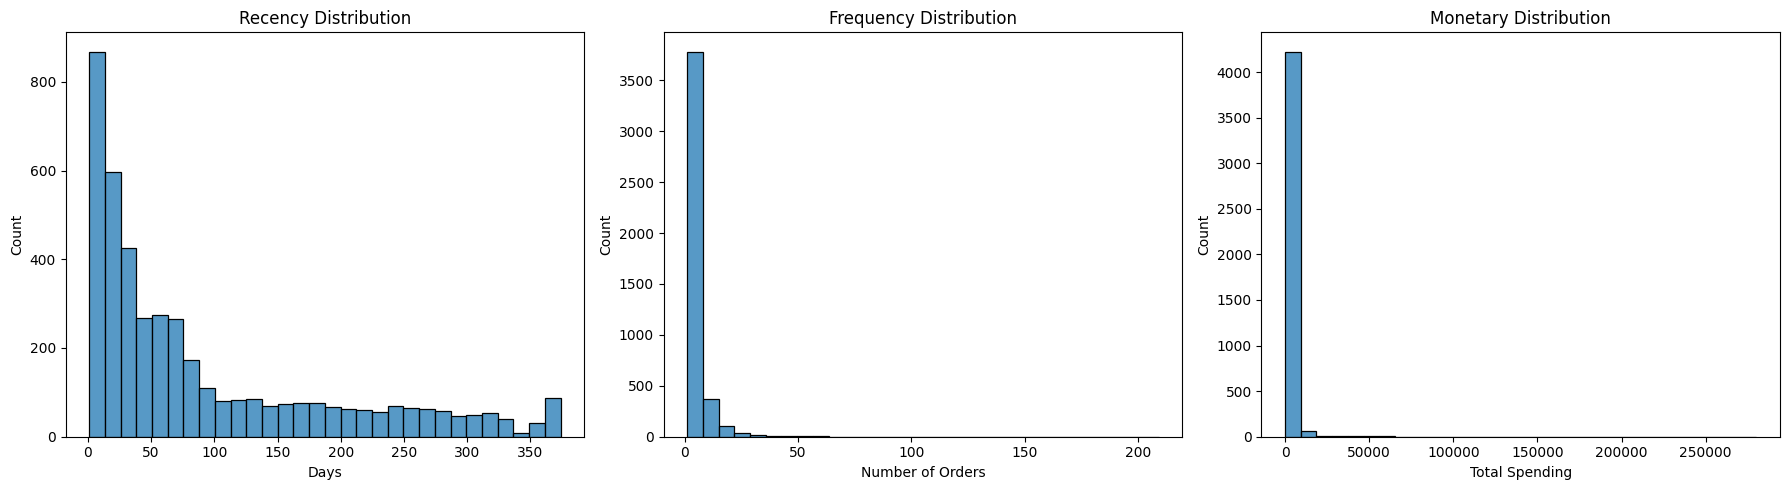

In [29]:
# RFM distributions

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days")

sns.histplot(rfm["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Orders")

sns.histplot(rfm["Monetary"], bins=30, ax=axes[2])
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total Spending")

plt.tight_layout()
plt.show()

In [30]:
# Day 2 - Transform RFM features

rfm_model = rfm[["Recency", "Frequency", "Monetary"]].copy()

# Log transformation
rfm_log = np.log1p(rfm_model)

print("Original RFM shape:", rfm_model.shape)
print("Transformed RFM shape:", rfm_log.shape)

print("\nTransformed RFM sample:")
print(rfm_log.head())

Original RFM shape: (4338, 3)
Transformed RFM shape: (4338, 3)

Transformed RFM sample:
    Recency  Frequency   Monetary
0  5.789960   0.693147  11.253955
1  1.098612   2.079442   8.368925
2  4.330733   1.609438   7.494564
3  2.995732   0.693147   7.472245
4  5.739793   0.693147   5.815324


In [31]:
# Standardize RFM features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

print("Scaled RFM:")
print(rfm_scaled.head())

print("\nMean after scaling:")
print(rfm_scaled.mean().round(4))

print("\nStandard deviation after scaling:")
print(rfm_scaled.std().round(4))

Scaled RFM:
    Recency  Frequency  Monetary
0  1.461993  -0.955214  3.707716
1 -2.038734   1.074425  1.414903
2  0.373104   0.386304  0.720024
3 -0.623086  -0.955214  0.702287
4  1.424558  -0.955214 -0.614514

Mean after scaling:
Recency     -0.0
Frequency   -0.0
Monetary    -0.0
dtype: float64

Standard deviation after scaling:
Recency      1.0001
Frequency    1.0001
Monetary     1.0001
dtype: float64


In [32]:
# Day 2 - Create final RFM dataset

rfm_final = rfm[["CustomerID"]].copy()

rfm_final["Recency"] = rfm_scaled["Recency"]
rfm_final["Frequency"] = rfm_scaled["Frequency"]
rfm_final["Monetary"] = rfm_scaled["Monetary"]

print("RFM final shape:", rfm_final.shape)
print("\nRFM final:")
print(rfm_final.head())

RFM final shape: (4338, 4)

RFM final:
   CustomerID   Recency  Frequency  Monetary
0     12346.0  1.461993  -0.955214  3.707716
1     12347.0 -2.038734   1.074425  1.414903
2     12348.0  0.373104   0.386304  0.720024
3     12349.0 -0.623086  -0.955214  0.702287
4     12350.0  1.424558  -0.955214 -0.614514


In [33]:
# Save RFM features

rfm_output_path = "../data/processed/rfm_features.csv"

rfm_final.to_csv(rfm_output_path, index=False)

print("RFM features saved successfully!")
print("File:", rfm_output_path)

RFM features saved successfully!
File: ../data/processed/rfm_features.csv


In [34]:
# Day 3 - Load RFM features

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rfm = pd.read_csv("../data/processed/rfm_features.csv")

print("RFM dataset shape:", rfm.shape)
print("\nColumns:")
print(rfm.columns.tolist())

print("\nFirst 5 rows:")
print(rfm.head())

RFM dataset shape: (4338, 4)

Columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary']

First 5 rows:
   CustomerID   Recency  Frequency  Monetary
0     12346.0  1.461993  -0.955214  3.707716
1     12347.0 -2.038734   1.074425  1.414903
2     12348.0  0.373104   0.386304  0.720024
3     12349.0 -0.623086  -0.955214  0.702287
4     12350.0  1.424558  -0.955214 -0.614514


In [35]:
# Select features for clustering

rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

print("Features used for clustering:")
print(rfm_features.head())

print("\nShape:", rfm_features.shape)

Features used for clustering:
    Recency  Frequency  Monetary
0  1.461993  -0.955214  3.707716
1 -2.038734   1.074425  1.414903
2  0.373104   0.386304  0.720024
3 -0.623086  -0.955214  0.702287
4  1.424558  -0.955214 -0.614514

Shape: (4338, 3)


In [36]:
# Test different numbers of clusters

k_values = range(2, 11)

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(rfm_features)
    
    score = silhouette_score(rfm_features, labels)
    silhouette_scores.append(score)
    
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.4328
K = 3, Silhouette Score = 0.3365
K = 4, Silhouette Score = 0.3375
K = 5, Silhouette Score = 0.3162
K = 6, Silhouette Score = 0.3124
K = 7, Silhouette Score = 0.3092
K = 8, Silhouette Score = 0.3033
K = 9, Silhouette Score = 0.2811
K = 10, Silhouette Score = 0.2767


In [37]:
from sklearn.cluster import KMeans

# K-Means with 6 customer segments
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

rfm_clustered = rfm_scaled.copy()

rfm_clustered["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed.")
print("\nCluster counts:")
print(rfm_clustered["Cluster"].value_counts().sort_index())

K-Means clustering completed.

Cluster counts:
Cluster
0    826
1    620
2    963
3    956
4    323
5    650
Name: count, dtype: int64


In [38]:
# Cluster profile
cluster_profile = rfm_clustered.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

print("Cluster profiles:")
print(cluster_profile.round(2))

Cluster profiles:
         Recency  Frequency  Monetary
Cluster                              
0          -0.30      -0.72     -0.78
1          -1.24       0.34      0.33
2           0.56      -0.17      0.16
3           1.16      -0.86     -1.00
4          -1.51       2.27      1.84
5          -0.22       0.97      1.00


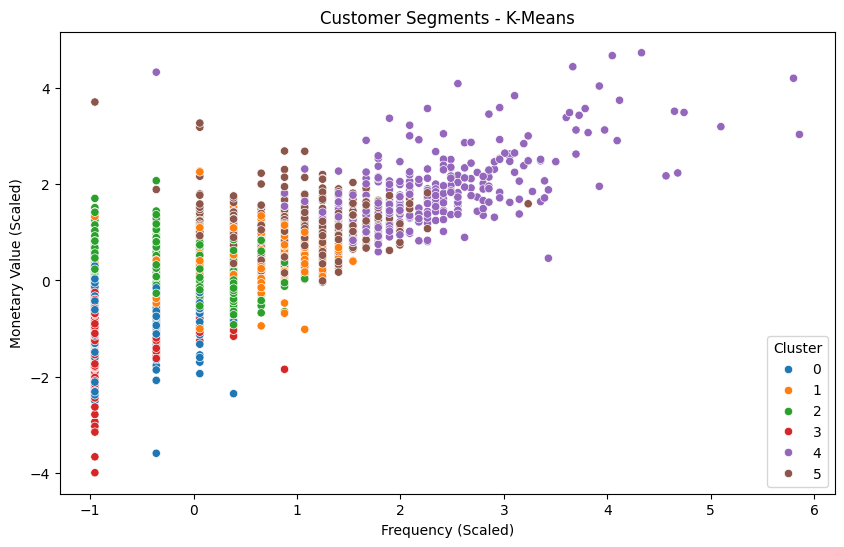

In [39]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm_clustered,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="tab10"
)

plt.title("Customer Segments - K-Means")
plt.xlabel("Frequency (Scaled)")
plt.ylabel("Monetary Value (Scaled)")
plt.legend(title="Cluster")
plt.show()

In [40]:
cluster_names = {
    0: "Low Value Customers",
    1: "Recent Regular Customers",
    2: "Occasional Customers",
    3: "At-Risk Low Value Customers",
    4: "High Value Loyal Customers",
    5: "High Value Customers"
}

rfm_clustered["Segment"] = rfm_clustered["Cluster"].map(cluster_names)

print(rfm_clustered[["Cluster", "Segment"]].drop_duplicates().sort_values("Cluster"))

    Cluster                      Segment
19        0          Low Value Customers
3         1     Recent Regular Customers
2         2         Occasional Customers
4         3  At-Risk Low Value Customers
1         4   High Value Loyal Customers
0         5         High Value Customers


In [41]:
# Add CustomerID back
rfm_segmented = rfm.copy()

rfm_segmented["Cluster"] = rfm_clustered["Cluster"]
rfm_segmented["Segment"] = rfm_clustered["Segment"]

output_path = "../data/processed/customer_segments.csv"

rfm_segmented.to_csv(output_path, index=False)

print("Customer segmentation saved successfully!")
print("File:", output_path)
print("Shape:", rfm_segmented.shape)

Customer segmentation saved successfully!
File: ../data/processed/customer_segments.csv
Shape: (4338, 6)


In [42]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# DBSCAN clustering
dbscan = DBSCAN(
    eps=0.5,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(rfm_scaled)

print("DBSCAN cluster labels:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN cluster labels:
-1      79
 0    2780
 1    1479
Name: count, dtype: int64


In [43]:
# Count noise points
noise_count = (dbscan_labels == -1).sum()

print("Noise points:", noise_count)

# Number of clusters excluding noise
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

print("Number of DBSCAN clusters:", n_clusters)

Noise points: 79
Number of DBSCAN clusters: 2


In [44]:
# Calculate DBSCAN silhouette score
# Noise points (-1) are excluded from the calculation

mask = dbscan_labels != -1

dbscan_silhouette = silhouette_score(
    rfm_scaled[mask],
    dbscan_labels[mask]
)

print("DBSCAN Silhouette Score:", round(dbscan_silhouette, 4))

DBSCAN Silhouette Score: 0.2939


In [45]:
print("K-Means Silhouette Score (K=6):", 0.3124)
print("DBSCAN Silhouette Score:", round(dbscan_silhouette, 4))

K-Means Silhouette Score (K=6): 0.3124
DBSCAN Silhouette Score: 0.2939


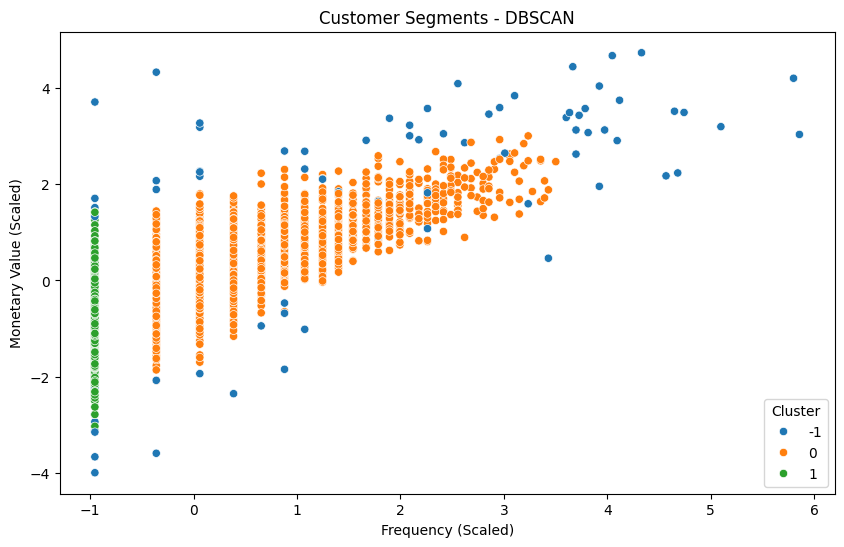

In [46]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=rfm_scaled["Frequency"],
    y=rfm_scaled["Monetary"],
    hue=dbscan_labels,
    palette="tab10"
)

plt.title("Customer Segments - DBSCAN")
plt.xlabel("Frequency (Scaled)")
plt.ylabel("Monetary Value (Scaled)")
plt.legend(title="Cluster")
plt.show()

In [47]:
# Day 3 - Clustering evaluation summary

clustering_results = pd.DataFrame({
    "Method": ["K-Means", "DBSCAN"],
    "Clusters": [6, n_clusters],
    "Noise_Points": [0, noise_count],
    "Silhouette_Score": [0.3124, dbscan_silhouette]
})

print(clustering_results)

    Method  Clusters  Noise_Points  Silhouette_Score
0  K-Means         6             0          0.312400
1   DBSCAN         2            79          0.293912


In [48]:
clustering_results.to_csv(
    "../data/processed/clustering_evaluation.csv",
    index=False
)

print("\nClustering evaluation saved successfully!")
print("File: ../data/processed/clustering_evaluation.csv")


Clustering evaluation saved successfully!
File: ../data/processed/clustering_evaluation.csv


In [49]:
# Day 4 - Time Series Preparation

print("Minimum date:", df_clean["InvoiceDate"].min())
print("Maximum date:", df_clean["InvoiceDate"].max())
print("Number of unique dates:", df_clean["InvoiceDate"].dt.date.nunique())

Minimum date: 2010-12-01 08:26:00
Maximum date: 2011-12-09 12:50:00
Number of unique dates: 305


In [50]:
# Calculate daily revenue

daily_revenue = (
    df_clean
    .set_index("InvoiceDate")
    .resample("D")["TotalRevenue"]
    .sum()
    .reset_index()
)

daily_revenue.head()

,InvoiceDate,TotalRevenue
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-04,0.00
4,2010-12-05,31361.28


In [51]:
print("Daily time-series shape:", daily_revenue.shape)

print("\nDate range:")
print(daily_revenue["InvoiceDate"].min())
print(daily_revenue["InvoiceDate"].max())

print("\nMissing revenue values:")
print(daily_revenue["TotalRevenue"].isna().sum())

Daily time-series shape: (374, 2)

Date range:
2010-12-01 00:00:00
2011-12-09 00:00:00

Missing revenue values:
0


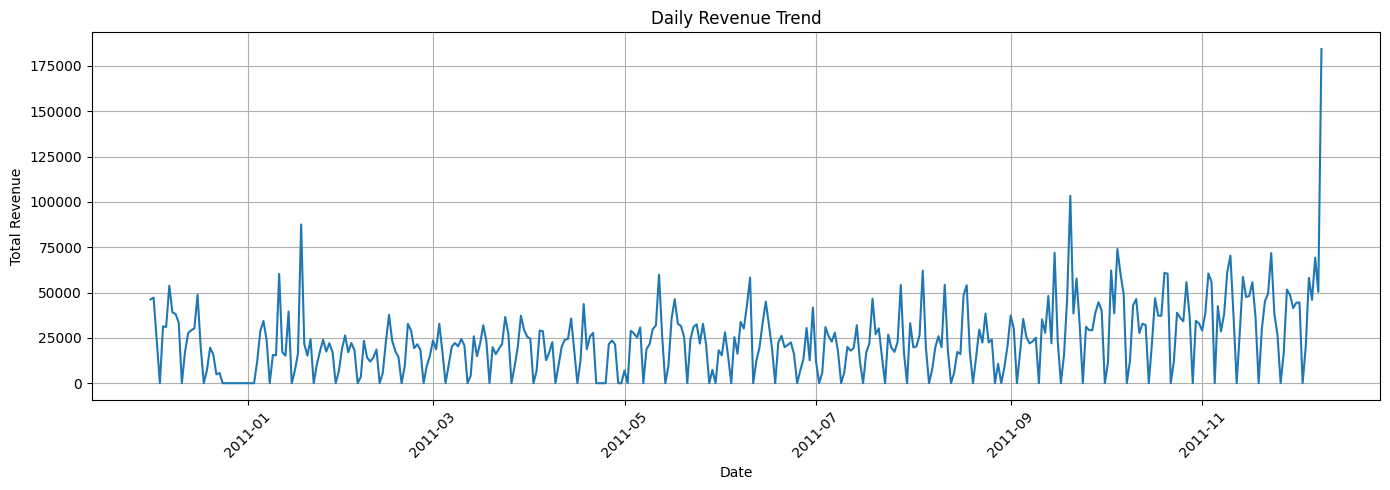

In [52]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_revenue["InvoiceDate"],
    daily_revenue["TotalRevenue"]
)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
# Weekly revenue aggregation

weekly_revenue = (
    daily_revenue
    .set_index("InvoiceDate")["TotalRevenue"]
    .resample("W")
    .sum()
    .reset_index()
)

print("Weekly time-series shape:", weekly_revenue.shape)

weekly_revenue.head()

Weekly time-series shape: (54, 2)


,InvoiceDate,TotalRevenue
0,2010-12-05,148627.97
1,2010-12-12,212619.13
2,2010-12-19,163116.12
3,2010-12-26,46059.51
4,2011-01-02,0.00


In [53]:
# Save daily time-series dataset

output_path = "../data/processed/daily_revenue.csv"

daily_revenue.to_csv(output_path, index=False)

print("Daily revenue dataset saved successfully!")
print("File:", output_path)

Daily revenue dataset saved successfully!
File: ../data/processed/daily_revenue.csv


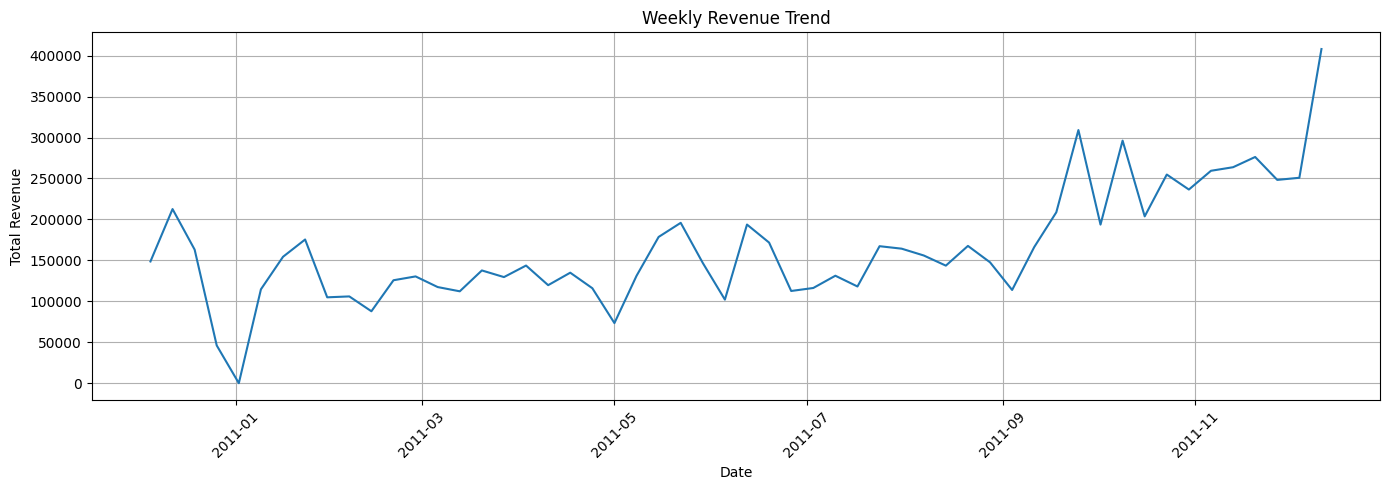

In [55]:
# Plot weekly revenue trend

plt.figure(figsize=(14, 5))

plt.plot(
    weekly_revenue["InvoiceDate"],
    weekly_revenue["TotalRevenue"]
)

plt.title("Weekly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [56]:
# Save weekly revenue dataset

output_path = "../data/processed/weekly_revenue.csv"

weekly_revenue.to_csv(output_path, index=False)

print("Weekly revenue dataset saved successfully!")
print("File:", output_path)

Weekly revenue dataset saved successfully!
File: ../data/processed/weekly_revenue.csv


In [57]:
# Prepare daily data for Prophet

prophet_data = daily_revenue.rename(
    columns={
        "InvoiceDate": "ds",
        "TotalRevenue": "y"
    }
)

print("Prophet dataset shape:", prophet_data.shape)
print("\nColumns:")
print(prophet_data.columns.tolist())

print("\nFirst 5 rows:")
print(prophet_data.head())

Prophet dataset shape: (374, 2)

Columns:
['ds', 'y']

First 5 rows:
          ds         y
0 2010-12-01  46192.49
1 2010-12-02  47197.57
2 2010-12-03  23876.63
3 2010-12-04      0.00
4 2010-12-05  31361.28


In [58]:
# Check Prophet data quality

print("Missing dates:", prophet_data["ds"].isna().sum())
print("Missing revenue:", prophet_data["y"].isna().sum())

print("Negative revenue values:", (prophet_data["y"] < 0).sum())

Missing dates: 0
Missing revenue: 0
Negative revenue values: 0


In [59]:
# Save Prophet-ready dataset

output_path = "../data/processed/prophet_daily.csv"

prophet_data.to_csv(output_path, index=False)

print("Prophet-ready dataset saved successfully!")
print("File:", output_path)

Prophet-ready dataset saved successfully!
File: ../data/processed/prophet_daily.csv


In [60]:
from prophet import Prophet

print("Prophet imported successfully!")

Importing plotly failed. Interactive plots will not work.


Prophet imported successfully!


In [62]:
# Create Prophet model
model = Prophet()

# Train model using the correct dataset name
model.fit(prophet_data)

print("Prophet model trained successfully!")

12:44:24 - cmdstanpy - INFO - Chain [1] start processing
12:44:24 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully!


In [63]:
model = Prophet()
model.fit(prophet_data)

print("Prophet model trained successfully!")

12:44:40 - cmdstanpy - INFO - Chain [1] start processing
12:44:41 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully!


In [64]:
future = model.make_future_dataframe(periods=30)

print("Future dataframe shape:", future.shape)
print(future.tail())

Future dataframe shape: (404, 1)
            ds
399 2012-01-04
400 2012-01-05
401 2012-01-06
402 2012-01-07
403 2012-01-08


In [65]:
forecast = model.predict(future)

print("Forecast generated successfully!")
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(30))

Forecast generated successfully!
            ds          yhat    yhat_lower    yhat_upper
374 2011-12-10  20616.120806   3396.790749  38323.346866
375 2011-12-11  35542.616829  18721.075687  52906.044460
376 2011-12-12  46556.307886  28222.300931  65395.424231
377 2011-12-13  52965.582849  35124.456463  69634.065818
378 2011-12-14  50499.268952  32335.564094  67368.818796
379 2011-12-15  57803.130657  40731.089182  75872.468131
380 2011-12-16  48832.758488  31261.949155  66203.760028
381 2011-12-17  21846.526705   4464.929631  40181.478586
382 2011-12-18  36773.022728  18917.260264  54439.142363
383 2011-12-19  47786.713785  29710.543033  64945.930982
384 2011-12-20  54195.988748  36166.705879  72953.514655
385 2011-12-21  51729.674851  34443.246899  69120.671936
386 2011-12-22  59033.536555  43060.921734  77237.783938
387 2011-12-23  50063.164387  32575.730578  68330.978143
388 2011-12-24  23076.932603   7077.013499  41282.844549
389 2011-12-25  38003.428627  19628.175198  56019.54274

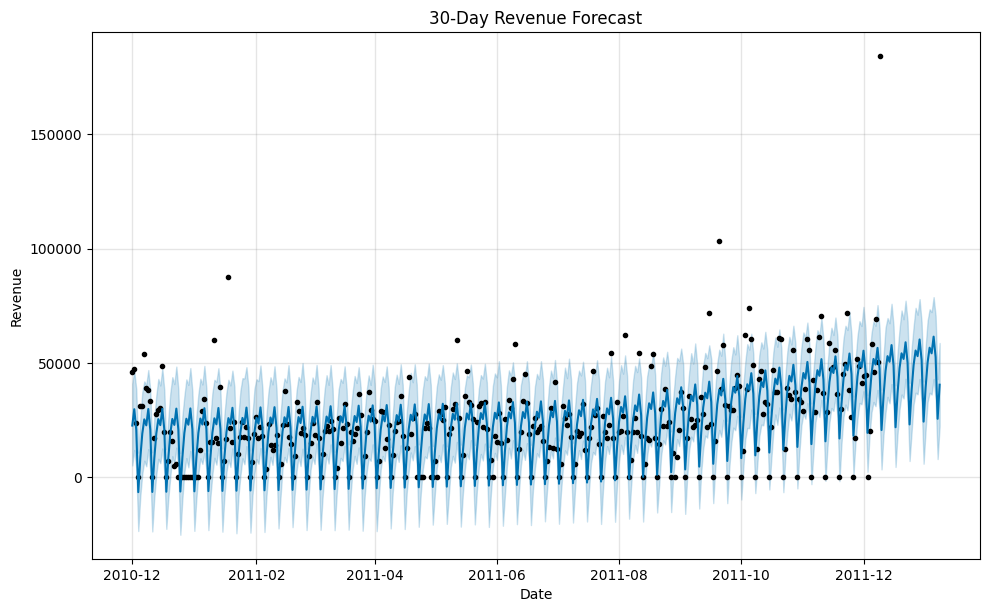

In [66]:
fig = model.plot(forecast)

plt.title("30-Day Revenue Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [67]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error

# Use the last 30 days as test data
train_data = prophet_data.iloc[:-30].copy()
test_data = prophet_data.iloc[-30:].copy()

# Train Prophet on training data
model_test = Prophet()
model_test.fit(train_data)

# Forecast the test period
future_test = model_test.make_future_dataframe(periods=30)
forecast_test = model_test.predict(future_test)

# Get predictions for the test dates
predictions = forecast_test[["ds", "yhat"]].tail(30).copy()

# Add actual values
predictions["actual"] = test_data["y"].values

# Calculate MAPE only where actual revenue is greater than zero
valid = predictions["actual"] > 0

mape = mean_absolute_percentage_error(
    predictions.loc[valid, "actual"],
    predictions.loc[valid, "yhat"]
) * 100

print(f"Prophet MAPE: {mape:.2f}%")

12:46:01 - cmdstanpy - INFO - Chain [1] start processing
12:46:01 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAPE: 22.69%


In [68]:
from prophet import Prophet

model_test = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="multiplicative"
)

model_test.fit(train_data)

future_test = model_test.make_future_dataframe(periods=30)
forecast_test = model_test.predict(future_test)

predictions = forecast_test[["ds", "yhat"]].tail(30).copy()
predictions["actual"] = test_data["y"].values

valid = predictions["actual"] > 0

mape = mean_absolute_percentage_error(
    predictions.loc[valid, "actual"],
    predictions.loc[valid, "yhat"]
) * 100

print(f"Improved Prophet MAPE: {mape:.2f}%")

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
12:46:33 - cmdstanpy - INFO - Chain [1] start processing
12:46:33 - cmdstanpy - INFO - Chain [1] done processing


Improved Prophet MAPE: 53.23%


In [69]:
model_test = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive"
)

model_test.fit(train_data)

future_test = model_test.make_future_dataframe(periods=30)
forecast_test = model_test.predict(future_test)

predictions = forecast_test[["ds", "yhat"]].tail(30).copy()
predictions["actual"] = test_data["y"].values

valid = predictions["actual"] > 0

mape = mean_absolute_percentage_error(
    predictions.loc[valid, "actual"],
    predictions.loc[valid, "yhat"]
) * 100

print(f"Weekly Prophet MAPE: {mape:.2f}%")

12:47:00 - cmdstanpy - INFO - Chain [1] start processing
12:47:00 - cmdstanpy - INFO - Chain [1] done processing


Weekly Prophet MAPE: 22.69%


In [70]:
model_test = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.1
)

model_test.fit(train_data)

future_test = model_test.make_future_dataframe(periods=30)
forecast_test = model_test.predict(future_test)

predictions = forecast_test[["ds", "yhat"]].tail(30).copy()
predictions["actual"] = test_data["y"].values

valid = predictions["actual"] > 0

mape = mean_absolute_percentage_error(
    predictions.loc[valid, "actual"],
    predictions.loc[valid, "yhat"]
) * 100

print(f"Flexible Trend Prophet MAPE: {mape:.2f}%")

12:47:22 - cmdstanpy - INFO - Chain [1] start processing
12:47:22 - cmdstanpy - INFO - Chain [1] done processing


Flexible Trend Prophet MAPE: 23.04%


### Prophet Model Evaluation

Several Prophet configurations were evaluated using a 30-day historical holdout period.

- Baseline Prophet: MAPE = 22.69%
- Yearly + weekly seasonality with multiplicative mode: MAPE = 53.23%
- Weekly seasonality: MAPE = 22.69%
- Increased changepoint flexibility: MAPE = 23.04%

The baseline Prophet configuration produced the lowest MAPE among the tested configurations and was retained as the Prophet baseline. The results indicate that additional yearly seasonality and increased trend flexibility did not improve validation performance.

In [71]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load daily revenue data
daily_revenue = pd.read_csv("../data/processed/daily_revenue.csv")

# Make sure the date column is datetime
daily_revenue["InvoiceDate"] = pd.to_datetime(daily_revenue["InvoiceDate"])

# Sort by date
daily_revenue = daily_revenue.sort_values("InvoiceDate").reset_index(drop=True)

# Select revenue
revenue = daily_revenue[["TotalRevenue"]].values

print("Total days:", len(revenue))
print("First date:", daily_revenue["InvoiceDate"].min())
print("Last date:", daily_revenue["InvoiceDate"].max())

Total days: 374
First date: 2010-12-01 00:00:00
Last date: 2011-12-09 00:00:00


In [72]:
from sklearn.preprocessing import MinMaxScaler

# Create scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Scale revenue
scaled_revenue = scaler.fit_transform(revenue)

print("Original minimum:", revenue.min())
print("Original maximum:", revenue.max())
print("Scaled minimum:", scaled_revenue.min())
print("Scaled maximum:", scaled_revenue.max())

Original minimum: 0.0
Original maximum: 184329.66
Scaled minimum: 0.0
Scaled maximum: 1.0


In [73]:
# Number of previous days used to predict the next day
look_back = 30

X = []
y = []

for i in range(look_back, len(scaled_revenue)):
    X.append(scaled_revenue[i-look_back:i, 0])
    y.append(scaled_revenue[i, 0])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (344, 30)
y shape: (344,)


In [74]:
# Reshape data for LSTM
X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape after reshaping:", X.shape)
print("y shape:", y.shape)

X shape after reshaping: (344, 30, 1)
y shape: (344,)


In [75]:
# Train-test split
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (275, 30, 1)
X_test shape: (69, 30, 1)
y_train shape: (275,)
y_test shape: (69,)


In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Create LSTM model
lstm_model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

# Compile model
lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# Display model architecture
lstm_model.summary()

C:\Users\heman\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0083 - val_loss: 0.0249
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0070 - val_loss: 0.0246
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0069 - val_loss: 0.0249
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0069 - val_loss: 0.0261
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0070 - val_loss: 0.0248
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0069 - val_loss: 0.0246
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0069 - val_loss: 0.0251
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0069 - val_loss: 0.0275
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0069 - val_loss: 0.0238
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0070 - val_loss: 0.0263
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0068 - val_loss: 0.0243
Epoch 12/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0

In [78]:
# Generate predictions on test data
y_pred_scaled = lstm_model.predict(X_test)

print("Prediction shape:", y_pred_scaled.shape)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step
Prediction shape: (69, 1)


In [79]:
# Convert scaled predictions back to original revenue values
y_pred = scaler.inverse_transform(y_pred_scaled)

# Convert scaled actual values back to original revenue values
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print("First 5 predicted values:")
print(y_pred[:5].flatten())

print("\nFirst 5 actual values:")
print(y_actual[:5].flatten())

First 5 predicted values:
[ -180.95792  5822.968   21800.545   21212.953   25454.094  ]

First 5 actual values:
[11479.98 62143.07 38532.09 73975.57 60258.53]


In [80]:
from sklearn.metrics import mean_absolute_percentage_error

# Calculate MAPE
lstm_mape = mean_absolute_percentage_error(
    y_actual,
    y_pred
) * 100

print(f"LSTM MAPE: {lstm_mape:.2f}%")

LSTM MAPE: 972217278500297506816.00%


In [81]:
# Check actual test values
print("Minimum actual revenue:", y_actual.min())
print("Number of zero actual values:", (y_actual == 0).sum())
print("Number of very small actual values:", (y_actual < 100).sum())

Minimum actual revenue: 0.0
Number of zero actual values: 9
Number of very small actual values: 9


In [82]:
# Exclude zero-revenue days from MAPE calculation
valid = y_actual.flatten() > 0

lstm_mape = mean_absolute_percentage_error(
    y_actual.flatten()[valid],
    y_pred.flatten()[valid]
) * 100

print("Valid days used for MAPE:", valid.sum())
print(f"LSTM MAPE: {lstm_mape:.2f}%")

Valid days used for MAPE: 60
LSTM MAPE: 44.77%


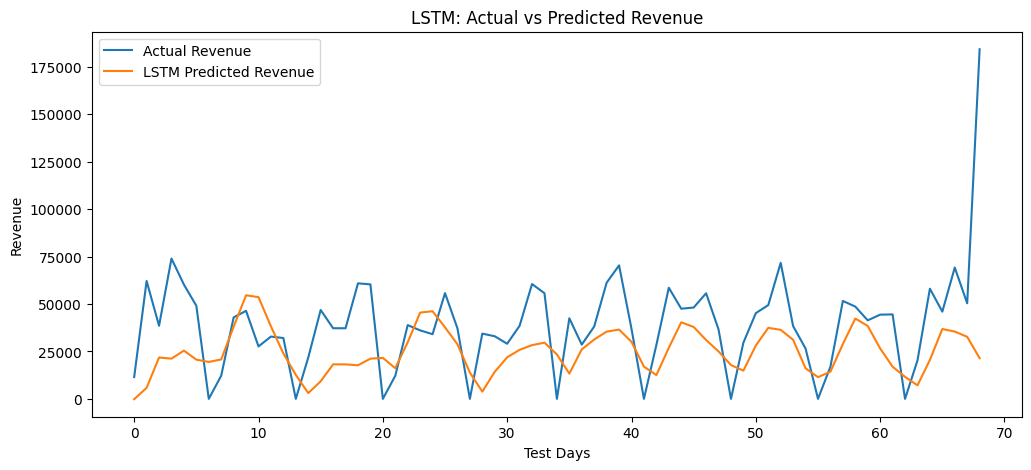

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y_actual.flatten(), label="Actual Revenue")
plt.plot(y_pred.flatten(), label="LSTM Predicted Revenue")

plt.title("LSTM: Actual vs Predicted Revenue")
plt.xlabel("Test Days")
plt.ylabel("Revenue")
plt.legend()
plt.show()

In [84]:
# Save LSTM evaluation result

lstm_results = pd.DataFrame({
    "Model": ["LSTM"],
    "MAPE": [lstm_mape],
    "Valid_Test_Days": [valid.sum()],
    "Excluded_Zero_Revenue_Days": [(~valid).sum()]
})

lstm_results.to_csv(
    "../data/processed/lstm_evaluation.csv",
    index=False
)

print(lstm_results)
print("\nSaved: ../data/processed/lstm_evaluation.csv")

  Model       MAPE  Valid_Test_Days  Excluded_Zero_Revenue_Days
0  LSTM  44.769603               60                           9

Saved: ../data/processed/lstm_evaluation.csv


In [85]:
import os

files_to_check = [
    "../data/processed/retail_clean.csv",
    "../data/processed/rfm_features.csv",
    "../data/processed/customer_segments.csv",
    "../data/processed/clustering_evaluation.csv",
    "../data/processed/daily_revenue.csv",
    "../data/processed/weekly_revenue.csv",
    "../data/processed/prophet_daily.csv",
    "../data/processed/lstm_evaluation.csv"
]

for file in files_to_check:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗ MISSING:", file)

✓ ../data/processed/retail_clean.csv
✓ ../data/processed/rfm_features.csv
✓ ../data/processed/customer_segments.csv
✓ ../data/processed/clustering_evaluation.csv
✓ ../data/processed/daily_revenue.csv
✓ ../data/processed/weekly_revenue.csv
✓ ../data/processed/prophet_daily.csv
✓ ../data/processed/lstm_evaluation.csv


In [86]:
import pandas as pd

# Load evaluation results
clustering_results = pd.read_csv(
    "../data/processed/clustering_evaluation.csv"
)

lstm_results = pd.read_csv(
    "../data/processed/lstm_evaluation.csv"
)

print("=== CLUSTERING RESULTS ===")
print(clustering_results)

print("\n=== LSTM RESULTS ===")
print(lstm_results)

print("\n=== PROPHET RESULT ===")
print("Prophet MAPE: 22.69%")

=== CLUSTERING RESULTS ===
    Method  Clusters  Noise_Points  Silhouette_Score
0  K-Means         6             0          0.312400
1   DBSCAN         2            79          0.293912

=== LSTM RESULTS ===
  Model       MAPE  Valid_Test_Days  Excluded_Zero_Revenue_Days
0  LSTM  44.769603               60                           9

=== PROPHET RESULT ===
Prophet MAPE: 22.69%


# Week 1 Checkpoint — RetailPulse

## Data Preparation
- Original transactions: 541,909
- Cleaned transactions: 392,692
- Customers available for RFM analysis: 4,338

## Customer Segmentation
- K-Means clusters: 6
- K-Means silhouette score: 0.3124
- DBSCAN clusters: 2
- DBSCAN noise points: 79
- DBSCAN silhouette score: 0.2939

K-Means with six clusters was used for the final customer segmentation to provide the required granular customer groups. The resulting segments were interpreted using Recency, Frequency, and Monetary characteristics.

## Demand Forecasting
- Prophet MAPE: 22.69%
- LSTM MAPE: 44.77%
- LSTM valid test days: 60
- Zero-revenue days excluded from LSTM MAPE: 9

The Prophet baseline produced a lower MAPE than the tested LSTM model on the evaluated historical periods. The LSTM captured general revenue movement but showed difficulty with sharp revenue peaks.

## Week 1 Status

Completed:
- Data loading and initial EDA
- Data cleaning
- RFM feature engineering
- K-Means and DBSCAN segmentation
- Daily and weekly time-series preparation
- Prophet forecasting
- LSTM forecasting
- Model evaluation
- Processed-data outputs saved

In [87]:
import pandas as pd

# Load cleaned transaction data
df_clean = pd.read_csv(
    "../data/processed/retail_clean.csv"
)

# Convert date column
df_clean["InvoiceDate"] = pd.to_datetime(
    df_clean["InvoiceDate"]
)

print("Rows:", len(df_clean))
print("Columns:", df_clean.columns.tolist())
print(df_clean.head())

Rows: 392692
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalRevenue', 'InvoiceMonth']
   InvoiceNo StockCode                          Description  Quantity  \
0     536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365     71053                  WHITE METAL LANTERN         6   
2     536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3     536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4     536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalRevenue  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom         15.30   
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom         20.34   
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom         22.00   
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom         20.34   
4 2010-12-

In [88]:
# Reference date: one day after the last transaction
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

# Create customer-level churn features
churn_features = (
    df_clean.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalRevenue", "sum"),
        TotalQuantity=("Quantity", "sum")
    )
    .reset_index()
)

# Average order value
churn_features["AverageOrderValue"] = (
    churn_features["Monetary"] /
    churn_features["Frequency"]
)

print("Customers:", len(churn_features))
print("Features:", churn_features.columns.tolist())
print(churn_features.head())

Customers: 4338
Features: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'AverageOrderValue']
   CustomerID  Recency  Frequency  Monetary  TotalQuantity  AverageOrderValue
0     12346.0      326          1  77183.60          74215       77183.600000
1     12347.0        2          7   4310.00           2458         615.714286
2     12348.0       75          4   1797.24           2341         449.310000
3     12349.0       19          1   1757.55            631        1757.550000
4     12350.0      310          1    334.40            197         334.400000


In [89]:
# Define churn target
churn_features["Churn"] = (
    churn_features["Recency"] > 90
).astype(int)

# Check churn distribution
print("Churn distribution:")
print(churn_features["Churn"].value_counts())

print("\nChurn percentage:")
print(churn_features["Churn"].value_counts(normalize=True) * 100)

Churn distribution:
Churn
0    2889
1    1449
Name: count, dtype: int64

Churn percentage:
Churn
0    66.59751
1    33.40249
Name: proportion, dtype: float64


In [90]:
from sklearn.model_selection import train_test_split

# Select model features
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "AverageOrderValue"
]

X = churn_features[features]
y = churn_features["Churn"]

# Split data while preserving the churn class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTraining churn distribution:")
print(y_train.value_counts())

print("\nTesting churn distribution:")
print(y_test.value_counts())

X_train: (3470, 5)
X_test: (868, 5)
y_train: (3470,)
y_test: (868,)

Training churn distribution:
Churn
0    2311
1    1159
Name: count, dtype: int64

Testing churn distribution:
Churn
0    578
1    290
Name: count, dtype: int64


In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create baseline Logistic Regression model
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [92]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# Predict churn labels
y_pred = logistic_model.predict(X_test)

# Predict churn probabilities
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Calculate metrics
roc_auc = roc_auc_score(y_test, y_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.9993
Precision: 1.0000
Recall: 0.9724

Confusion Matrix:
[[578   0]
 [  8 282]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       578
           1       1.00      0.97      0.99       290

    accuracy                           0.99       868
   macro avg       0.99      0.99      0.99       868
weighted avg       0.99      0.99      0.99       868



In [93]:
features_no_recency = [
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "AverageOrderValue"
]

X = churn_features[features_no_recency]
y = churn_features["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

logistic_model_no_recency = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

logistic_model_no_recency.fit(X_train, y_train)

print("Model trained without Recency.")

Model trained without Recency.


In [94]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred_no_recency = logistic_model_no_recency.predict(X_test)
y_prob_no_recency = logistic_model_no_recency.predict_proba(X_test)[:, 1]

# Metrics
roc_auc_no_recency = roc_auc_score(y_test, y_prob_no_recency)
precision_no_recency = precision_score(y_test, y_pred_no_recency)
recall_no_recency = recall_score(y_test, y_pred_no_recency)

print(f"ROC-AUC: {roc_auc_no_recency:.4f}")
print(f"Precision: {precision_no_recency:.4f}")
print(f"Recall: {recall_no_recency:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_no_recency))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_no_recency))

ROC-AUC: 0.7930
Precision: 0.6171
Recall: 0.5724

Confusion Matrix:
[[475 103]
 [124 166]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.81       578
           1       0.62      0.57      0.59       290

    accuracy                           0.74       868
   macro avg       0.71      0.70      0.70       868
weighted avg       0.73      0.74      0.74       868



In [95]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [96]:
# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Metrics
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

print(f"ROC-AUC: {roc_auc_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

ROC-AUC: 0.7493
Precision: 0.5814
Recall: 0.4310

Confusion Matrix:
[[488  90]
 [165 125]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.84      0.79       578
           1       0.58      0.43      0.50       290

    accuracy                           0.71       868
   macro avg       0.66      0.64      0.64       868
weighted avg       0.69      0.71      0.69       868



In [97]:
import numpy as np

# Create a table with actual churn and predicted probability
top20_results = pd.DataFrame({
    "Actual_Churn": y_test.values,
    "Churn_Probability": y_prob_no_recency
})

# Sort customers from highest to lowest churn probability
top20_results = top20_results.sort_values(
    "Churn_Probability",
    ascending=False
)

# Select the top 20%
top20_count = int(len(top20_results) * 0.20)

top20_customers = top20_results.head(top20_count)

# Calculate Precision@Top 20%
precision_at_20 = top20_customers["Actual_Churn"].mean()

print("Total test customers:", len(top20_results))
print("Top 20% customers:", top20_count)
print(f"Precision@Top 20%: {precision_at_20:.4f}")

Total test customers: 868
Top 20% customers: 173
Precision@Top 20%: 0.6185


In [98]:
# Create additional behavioral features

customer_behavior = (
    df_clean.groupby("CustomerID")
    .agg(
        ActiveMonths=("InvoiceDate", lambda x: x.dt.to_period("M").nunique()),
        UniqueProducts=("StockCode", "nunique"),
        CountryCount=("Country", "nunique")
    )
    .reset_index()
)

# Calculate average days between orders
order_dates = (
    df_clean.groupby(["CustomerID", "InvoiceNo"])["InvoiceDate"]
    .max()
    .reset_index()
)

avg_days = (
    order_dates.sort_values(["CustomerID", "InvoiceDate"])
    .groupby("CustomerID")["InvoiceDate"]
    .diff()
    .dt.days
    .groupby(order_dates["CustomerID"])
    .mean()
    .reset_index(name="AverageDaysBetweenOrders")
)

# Merge new features
churn_features_v2 = churn_features.merge(
    customer_behavior,
    on="CustomerID",
    how="left"
)

churn_features_v2 = churn_features_v2.merge(
    avg_days,
    on="CustomerID",
    how="left"
)

churn_features_v2["AverageDaysBetweenOrders"] = (
    churn_features_v2["AverageDaysBetweenOrders"].fillna(0)
)

print(churn_features_v2.shape)
print(churn_features_v2.head())

(4338, 11)
   CustomerID  Recency  Frequency  Monetary  TotalQuantity  AverageOrderValue  \
0     12346.0      326          1  77183.60          74215       77183.600000   
1     12347.0        2          7   4310.00           2458         615.714286   
2     12348.0       75          4   1797.24           2341         449.310000   
3     12349.0       19          1   1757.55            631        1757.550000   
4     12350.0      310          1    334.40            197         334.400000   

   Churn  ActiveMonths  UniqueProducts  CountryCount  AverageDaysBetweenOrders  
0      1             1               1             1                  0.000000  
1      0             7             103             1                 60.333333  
2      0             4              22             1                 94.000000  
3      0             1              73             1                  0.000000  
4      1             1              17             1                  0.000000  


In [99]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

features_v2 = [
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "AverageOrderValue",
    "ActiveMonths",
    "UniqueProducts",
    "CountryCount",
    "AverageDaysBetweenOrders"
]

X_v2 = churn_features_v2[features_v2]
y_v2 = churn_features_v2["Churn"]

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=0.20,
    random_state=42,
    stratify=y_v2
)

logistic_model_v2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=2000
    ))
])

logistic_model_v2.fit(X_train_v2, y_train_v2)

print("Improved Logistic Regression model trained successfully!")
print("Training shape:", X_train_v2.shape)
print("Testing shape:", X_test_v2.shape)

Improved Logistic Regression model trained successfully!
Training shape: (3470, 8)
Testing shape: (868, 8)


In [100]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred_v2 = logistic_model_v2.predict(X_test_v2)
y_prob_v2 = logistic_model_v2.predict_proba(X_test_v2)[:, 1]

# Metrics
roc_auc_v2 = roc_auc_score(y_test_v2, y_prob_v2)
precision_v2 = precision_score(y_test_v2, y_pred_v2)
recall_v2 = recall_score(y_test_v2, y_pred_v2)

print(f"ROC-AUC: {roc_auc_v2:.4f}")
print(f"Precision: {precision_v2:.4f}")
print(f"Recall: {recall_v2:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_v2, y_pred_v2))

print("\nClassification Report:")
print(classification_report(y_test_v2, y_pred_v2))

ROC-AUC: 0.8087
Precision: 0.6224
Recall: 0.6310

Confusion Matrix:
[[467 111]
 [107 183]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       578
           1       0.62      0.63      0.63       290

    accuracy                           0.75       868
   macro avg       0.72      0.72      0.72       868
weighted avg       0.75      0.75      0.75       868



In [101]:
# Create results table
top20_v2 = pd.DataFrame({
    "Actual_Churn": y_test_v2.values,
    "Churn_Probability": y_prob_v2
})

# Sort by predicted churn probability
top20_v2 = top20_v2.sort_values(
    "Churn_Probability",
    ascending=False
)

# Select top 20%
top20_count_v2 = int(len(top20_v2) * 0.20)

top20_customers_v2 = top20_v2.head(top20_count_v2)

# Precision@Top 20%
precision_at_20_v2 = top20_customers_v2["Actual_Churn"].mean()

print("Total test customers:", len(top20_v2))
print("Top 20% customers:", top20_count_v2)
print(f"Precision@Top 20%: {precision_at_20_v2:.4f}")

Total test customers: 868
Top 20% customers: 173
Precision@Top 20%: 0.6416


In [102]:
churn_results = pd.DataFrame({
    "Model": [
        "Logistic Regression - Leakage Free",
        "Random Forest - Leakage Free",
        "Improved Logistic Regression"
    ],
    "ROC_AUC": [
        0.7930,
        0.7493,
        0.8087
    ],
    "Precision": [
        0.6171,
        0.5814,
        0.6224
    ],
    "Recall": [
        0.5724,
        0.4310,
        0.6310
    ],
    "Precision_at_Top_20": [
        0.6185,
        None,
        0.6416
    ]
})

churn_results.to_csv(
    "../data/processed/churn_model_evaluation.csv",
    index=False
)

print(churn_results)
print("\nSaved to ../data/processed/churn_model_evaluation.csv")

                                Model  ROC_AUC  Precision  Recall  \
0  Logistic Regression - Leakage Free   0.7930     0.6171  0.5724   
1        Random Forest - Leakage Free   0.7493     0.5814  0.4310   
2        Improved Logistic Regression   0.8087     0.6224  0.6310   

   Precision_at_Top_20  
0               0.6185  
1                  NaN  
2               0.6416  

Saved to ../data/processed/churn_model_evaluation.csv


In [103]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_v2, y_train_v2)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [104]:
# Predictions
y_pred_gb = gb_model.predict(X_test_v2)
y_prob_gb = gb_model.predict_proba(X_test_v2)[:, 1]

# Metrics
roc_auc_gb = roc_auc_score(y_test_v2, y_prob_gb)
precision_gb = precision_score(y_test_v2, y_pred_gb)
recall_gb = recall_score(y_test_v2, y_pred_gb)

print(f"ROC-AUC: {roc_auc_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_v2, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test_v2, y_pred_gb))

ROC-AUC: 0.8175
Precision: 0.6255
Recall: 0.5586

Confusion Matrix:
[[481  97]
 [128 162]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       578
           1       0.63      0.56      0.59       290

    accuracy                           0.74       868
   macro avg       0.71      0.70      0.70       868
weighted avg       0.73      0.74      0.74       868



In [105]:
# Create results table
gb_top20 = pd.DataFrame({
    "Actual_Churn": y_test_v2.values,
    "Churn_Probability": y_prob_gb
})

# Sort by highest predicted churn probability
gb_top20 = gb_top20.sort_values(
    "Churn_Probability",
    ascending=False
)

# Select top 20%
top20_count_gb = int(len(gb_top20) * 0.20)

gb_top20_customers = gb_top20.head(top20_count_gb)

# Calculate Precision@Top 20%
precision_at_20_gb = gb_top20_customers["Actual_Churn"].mean()

print("Total test customers:", len(gb_top20))
print("Top 20% customers:", top20_count_gb)
print(f"Precision@Top 20%: {precision_at_20_gb:.4f}")

Total test customers: 868
Top 20% customers: 173
Precision@Top 20%: 0.6416


In [106]:
gb_result = pd.DataFrame({
    "Model": ["Gradient Boosting"],
    "ROC_AUC": [roc_auc_gb],
    "Precision": [precision_gb],
    "Recall": [recall_gb],
    "Precision_at_Top_20": [precision_at_20_gb]
})

churn_results_updated = pd.concat(
    [churn_results, gb_result],
    ignore_index=True
)

churn_results_updated.to_csv(
    "../data/processed/churn_model_evaluation.csv",
    index=False
)

print(churn_results_updated)
print("\nUpdated churn evaluation saved successfully!")

                                Model   ROC_AUC  Precision    Recall  \
0  Logistic Regression - Leakage Free  0.793000   0.617100  0.572400   
1        Random Forest - Leakage Free  0.749300   0.581400  0.431000   
2        Improved Logistic Regression  0.808700   0.622400  0.631000   
3                   Gradient Boosting  0.817513   0.625483  0.558621   

   Precision_at_Top_20  
0             0.618500  
1                  NaN  
2             0.641600  
3             0.641618  

Updated churn evaluation saved successfully!


In [108]:
import os

os.makedirs("../models", exist_ok=True)

print("Models folder created successfully!")

Models folder created successfully!


In [109]:
import joblib

joblib.dump(
    gb_model,
    "../models/churn_gradient_boosting.pkl"
)

print("Gradient Boosting churn model saved successfully!")

Gradient Boosting churn model saved successfully!


In [110]:
import joblib

loaded_gb_model = joblib.load(
    "../models/churn_gradient_boosting.pkl"
)

print("Model loaded successfully!")
print(type(loaded_gb_model))

Model loaded successfully!
<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>


In [111]:
# Prepare all customer features
X_all_churn = churn_features_v2[features_v2]

# Predict churn probability for every customer
all_churn_probabilities = loaded_gb_model.predict_proba(
    X_all_churn
)[:, 1]

# Create final customer churn table
churn_predictions = churn_features_v2[
    ["CustomerID", "Churn"]
].copy()

churn_predictions["ChurnProbability"] = all_churn_probabilities

# Add risk category
churn_predictions["RiskLevel"] = pd.cut(
    churn_predictions["ChurnProbability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"]
)

# Sort highest risk first
churn_predictions = churn_predictions.sort_values(
    "ChurnProbability",
    ascending=False
)

print("Customers:", len(churn_predictions))
print("\nRisk distribution:")
print(churn_predictions["RiskLevel"].value_counts())

print("\nTop 10 highest-risk customers:")
print(churn_predictions.head(10))

Customers: 4338

Risk distribution:
RiskLevel
Low       1991
Medium    1663
High       684
Name: count, dtype: int64

Top 10 highest-risk customers:
      CustomerID  Churn  ChurnProbability RiskLevel
824      13452.0      1          0.905098      High
2933     16349.0      1          0.900988      High
785      13391.0      1          0.899846      High
1471     14351.0      1          0.899846      High
635      13185.0      1          0.895205      High
2734     16078.0      1          0.895205      High
1037     13747.0      1          0.895205      High
719      13302.0      1          0.895205      High
3950     17747.0      1          0.895205      High
576      13106.0      1          0.895205      High


In [112]:
churn_predictions.to_csv(
    "../data/processed/churn_predictions.csv",
    index=False
)

print("Churn predictions saved successfully!")
print("File: ../data/processed/churn_predictions.csv")

Churn predictions saved successfully!
File: ../data/processed/churn_predictions.csv


In [113]:
# Load cleaned retail data
df_clean = pd.read_csv("../data/processed/retail_clean.csv")

# Convert InvoiceDate to datetime
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

print("Rows:", len(df_clean))
print("Unique products:", df_clean["StockCode"].nunique())

Rows: 392692
Unique products: 3665


In [114]:
# Calculate product-level demand
product_demand = (
    df_clean
    .groupby(["StockCode", "Description"])
    .agg(
        TotalQuantity=("Quantity", "sum"),
        TotalRevenue=("TotalRevenue", "sum"),
        NumberOfOrders=("InvoiceNo", "nunique")
    )
    .reset_index()
)

print("Product demand shape:", product_demand.shape)
print("\nTop 10 products by quantity sold:")
print(
    product_demand
    .sort_values("TotalQuantity", ascending=False)
    .head(10)
)

Product demand shape: (3897, 5)

Top 10 products by quantity sold:
     StockCode                         Description  TotalQuantity  \
2602     23843         PAPER CRAFT , LITTLE BIRDIE          80995   
2100     23166      MEDIUM CERAMIC TOP STORAGE JAR          77916   
3020     84077   WORLD WAR 2 GLIDERS ASSTD DESIGNS          54319   
3444    85099B             JUMBO BAG RED RETROSPOT          46078   
3459    85123A  WHITE HANGING HEART T-LIGHT HOLDER          36706   
3278     84879       ASSORTED COLOUR BIRD ORNAMENT          35263   
432      21212     PACK OF 72 RETROSPOT CAKE CASES          33670   
1108     22197                      POPCORN HOLDER          30919   
2006     23084                  RABBIT NIGHT LIGHT          27153   
1383     22492             MINI PAINT SET VINTAGE           26076   

      TotalRevenue  NumberOfOrders  
2602     168469.60               1  
2100      81416.73             195  
3020      13558.41             472  
3444      85040.54       

In [115]:
# Product-level daily demand
product_daily_demand = (
    df_clean
    .groupby([
        pd.Grouper(key="InvoiceDate", freq="D"),
        "StockCode"
    ])["Quantity"]
    .sum()
    .reset_index()
)

print("Daily demand shape:", product_daily_demand.shape)
print(product_daily_demand.head())

Daily demand shape: (222370, 3)
  InvoiceDate StockCode  Quantity
0  2010-12-01     10002        60
1  2010-12-01     10125         2
2  2010-12-01     10133         5
3  2010-12-01    15044B         1
4  2010-12-01   15056BL        20


In [116]:
# Calculate demand statistics for each product
demand_stats = (
    product_daily_demand
    .groupby("StockCode")["Quantity"]
    .agg(
        AverageDailyDemand="mean",
        DemandStd="std",
        MaximumDailyDemand="max",
        DemandDays="count"
    )
    .reset_index()
)

demand_stats["DemandStd"] = demand_stats["DemandStd"].fillna(0)

print("Demand statistics shape:", demand_stats.shape)
print("\nTop 10 products by average daily demand:")
print(
    demand_stats
    .sort_values("AverageDailyDemand", ascending=False)
    .head(10)
)

Demand statistics shape: (3665, 5)

Top 10 products by average daily demand:
     StockCode  AverageDailyDemand    DemandStd  MaximumDailyDemand  \
2399     23843        80995.000000     0.000000               80995   
2590    47556B         1300.000000     0.000000                1300   
1997     23166          677.530435  6917.726161               74215   
2898     84568          501.818182   492.127320                1728   
108      18007          418.285714  1022.650134                3206   
1919     23084          288.861702   468.096089                2647   
29       16014          272.000000   635.741496                3020   
2919     84598          249.600000    85.865010                 288   
2804     84077          241.417778   487.330139                4848   
33       16033          210.000000   180.000000                 480   

      DemandDays  
2399           1  
2590           2  
1997         115  
2898          22  
108           14  
1919          94  
29      

In [117]:
# Create a complete daily demand history for every product
date_range = pd.date_range(
    start=df_clean["InvoiceDate"].min().normalize(),
    end=df_clean["InvoiceDate"].max().normalize(),
    freq="D"
)

products = df_clean["StockCode"].dropna().unique()

# Aggregate actual daily sales
daily_product_sales = (
    df_clean
    .assign(SalesDate=df_clean["InvoiceDate"].dt.normalize())
    .groupby(["SalesDate", "StockCode"])["Quantity"]
    .sum()
)

# Create all date-product combinations
full_index = pd.MultiIndex.from_product(
    [date_range, products],
    names=["SalesDate", "StockCode"]
)

# Fill days without sales with zero
product_daily_complete = (
    daily_product_sales
    .reindex(full_index, fill_value=0)
    .reset_index()
)

print("Complete daily demand shape:", product_daily_complete.shape)
print(product_daily_complete.head())

Complete daily demand shape: (1370710, 3)
   SalesDate StockCode  Quantity
0 2010-12-01    85123A       441
1 2010-12-01     71053        32
2 2010-12-01    84406B        40
3 2010-12-01    84029G        56
4 2010-12-01    84029E       549


In [118]:
# Calculate demand statistics including zero-sales days
demand_stats = (
    product_daily_complete
    .groupby("StockCode")["Quantity"]
    .agg(
        AverageDailyDemand="mean",
        DemandStd="std",
        MaximumDailyDemand="max",
        DemandDays=lambda x: (x > 0).sum()
    )
    .reset_index()
)

demand_stats["DemandStd"] = demand_stats["DemandStd"].fillna(0)

print("Demand statistics shape:", demand_stats.shape)

print("\nTop 10 products by average daily demand:")
print(
    demand_stats
    .sort_values("AverageDailyDemand", ascending=False)
    .head(10)
)

Demand statistics shape: (3665, 5)

Top 10 products by average daily demand:
     StockCode  AverageDailyDemand    DemandStd  MaximumDailyDemand  \
2399     23843          216.564171  4188.151745               80995   
1997     23166          208.331551  3837.175541               74215   
2804     84077          145.237968   395.762744                4848   
1088     22197          131.443850   343.555188                4300   
3219    85099B          123.203209   177.823108                1580   
3233    85123A           98.296791   222.771611                3114   
3059     84879           94.286096   208.109532                3335   
423      21212           90.026738   170.415843                1540   
1919     23084           72.601604   265.282022                2647   
1352     22492           69.721925   163.477762                1394   

      DemandDays  
2399           1  
1997         115  
2804         225  
1088         284  
3219         296  
3233         305  
3059    

In [119]:
# Assume a 7-day supplier lead time
lead_time_days = 7

# Calculate safety stock using 95% service-level z-score
z_score = 1.65

demand_stats["SafetyStock"] = (
    z_score
    * demand_stats["DemandStd"]
    * np.sqrt(lead_time_days)
)

# Calculate reorder point
demand_stats["ReorderPoint"] = (
    demand_stats["AverageDailyDemand"] * lead_time_days
    + demand_stats["SafetyStock"]
)

print("Reorder point calculated successfully!")

print("\nTop 10 products by reorder point:")
print(
    demand_stats[
        [
            "StockCode",
            "AverageDailyDemand",
            "DemandStd",
            "SafetyStock",
            "ReorderPoint"
        ]
    ]
    .sort_values("ReorderPoint", ascending=False)
    .head(10)
)

Reorder point calculated successfully!

Top 10 products by reorder point:
     StockCode  AverageDailyDemand    DemandStd   SafetyStock  ReorderPoint
2399     23843          216.564171  4188.151745  18283.333151  19799.282349
1997     23166          208.331551  3837.175541  16751.150160  18209.471015
2804     84077          145.237968   395.762744   1727.698169   2744.363944
1088     22197          131.443850   343.555188   1499.786621   2419.893573
1919     23084           72.601604   265.282022   1158.085926   1666.297156
3233    85123A           98.296791   222.771611    972.507163   1660.584704
3219    85099B          123.203209   177.823108    776.284941   1638.707400
3059     84879           94.286096   208.109532    908.500012   1568.502686
423      21212           90.026738   170.415843    743.948602   1374.135768
29       16014           35.636364   245.879079   1073.382578   1322.837124


In [120]:
# Calculate reorder-point thresholds
low_threshold = demand_stats["ReorderPoint"].quantile(0.50)
high_threshold = demand_stats["ReorderPoint"].quantile(0.90)

# Create inventory recommendation
demand_stats["InventoryPriority"] = pd.cut(
    demand_stats["ReorderPoint"],
    bins=[-np.inf, low_threshold, high_threshold, np.inf],
    labels=["Low", "Medium", "High"]
)

# Round values for easier reporting
inventory_recommendations = demand_stats.copy()

for column in [
    "AverageDailyDemand",
    "DemandStd",
    "SafetyStock",
    "ReorderPoint"
]:
    inventory_recommendations[column] = (
        inventory_recommendations[column].round(2)
    )

print("Inventory recommendations created!")

print("\nPriority distribution:")
print(
    inventory_recommendations["InventoryPriority"]
    .value_counts()
    .sort_index()
)

Inventory recommendations created!

Priority distribution:
InventoryPriority
Low       1833
Medium    1465
High       367
Name: count, dtype: int64


In [121]:
print("\nTop 15 products requiring inventory attention:")

print(
    inventory_recommendations[
        [
            "StockCode",
            "AverageDailyDemand",
            "DemandStd",
            "SafetyStock",
            "ReorderPoint",
            "InventoryPriority"
        ]
    ]
    .sort_values("ReorderPoint", ascending=False)
    .head(15)
)


Top 15 products requiring inventory attention:
     StockCode  AverageDailyDemand  DemandStd  SafetyStock  ReorderPoint  \
2399     23843              216.56    4188.15     18283.33      19799.28   
1997     23166              208.33    3837.18     16751.15      18209.47   
2804     84077              145.24     395.76      1727.70       2744.36   
1088     22197              131.44     343.56      1499.79       2419.89   
1919     23084               72.60     265.28      1158.09       1666.30   
3233    85123A               98.30     222.77       972.51       1660.58   
3219    85099B              123.20     177.82       776.28       1638.71   
3059     84879               94.29     208.11       908.50       1568.50   
423      21212               90.03     170.42       743.95       1374.14   
29       16014               35.64     245.88      1073.38       1322.84   
1469     22616               67.72     189.21       826.01       1300.09   
910      21977               64.79     1

In [122]:
inventory_recommendations.to_csv(
    "../data/processed/inventory_recommendations.csv",
    index=False
)

print("Inventory recommendations saved successfully!")
print("File: ../data/processed/inventory_recommendations.csv")

Inventory recommendations saved successfully!
File: ../data/processed/inventory_recommendations.csv


In [123]:
print(
    inventory_recommendations[
        ["StockCode", "ReorderPoint", "InventoryPriority"]
    ].head()
)

  StockCode  ReorderPoint InventoryPriority
0     10002         66.26            Medium
1     10080         23.59               Low
2     10120         17.59               Low
3    10123C          0.84               Low
4    10124A          2.01               Low


In [124]:
id="v7kq3m"
# Get product descriptions
product_info = (
    df_clean[["StockCode", "Description"]]
    .drop_duplicates("StockCode")
)

# Add descriptions to inventory recommendations
inventory_recommendations = inventory_recommendations.merge(
    product_info,
    on="StockCode",
    how="left"
)

# Reorder columns
inventory_recommendations = inventory_recommendations[
    [
        "StockCode",
        "Description",
        "AverageDailyDemand",
        "DemandStd",
        "SafetyStock",
        "ReorderPoint",
        "InventoryPriority"
    ]
]

print("Product descriptions added successfully!")

print(
    inventory_recommendations.head(10)
)

Product descriptions added successfully!
  StockCode                   Description  AverageDailyDemand  DemandStd  \
0     10002   INFLATABLE POLITICAL GLOBE                 2.20      11.65   
1     10080      GROOVY CACTUS INFLATABLE                0.78       4.16   
2     10120                  DOGGY RUBBER                0.51       3.21   
3    10123C         HEARTS WRAPPING TAPE                 0.01       0.17   
4    10124A   SPOTS ON RED BOOKCOVER TAPE                0.04       0.39   
5    10124G      ARMY CAMO BOOKCOVER TAPE                0.05       0.44   
6     10125       MINI FUNKY DESIGN TAPES                3.28      14.00   
7     10133  COLOURING PENCILS BROWN TUBE                6.34      18.37   
8     10135  COLOURING PENCILS BROWN TUBE                5.18      19.07   
9     11001   ASSTD DESIGN RACING CAR PEN                3.35      21.15   

   SafetyStock  ReorderPoint InventoryPriority  
0        50.86         66.26            Medium  
1        18.14         2

In [125]:
inventory_recommendations.to_csv(
    "../data/processed/inventory_recommendations.csv",
    index=False
)

print("Updated inventory recommendations saved!")

Updated inventory recommendations saved!


In [126]:
print("Inventory recommendations:", len(inventory_recommendations))
print("\nColumns:")
print(inventory_recommendations.columns.tolist())

print("\nPriority distribution:")
print(inventory_recommendations["InventoryPriority"].value_counts())

print("\nTop 10 inventory priorities:")
print(
    inventory_recommendations[
        [
            "StockCode",
            "Description",
            "AverageDailyDemand",
            "SafetyStock",
            "ReorderPoint",
            "InventoryPriority"
        ]
    ]
    .sort_values("ReorderPoint", ascending=False)
    .head(10)
)

Inventory recommendations: 3665

Columns:
['StockCode', 'Description', 'AverageDailyDemand', 'DemandStd', 'SafetyStock', 'ReorderPoint', 'InventoryPriority']

Priority distribution:
InventoryPriority
Low       1833
Medium    1465
High       367
Name: count, dtype: int64

Top 10 inventory priorities:
     StockCode                         Description  AverageDailyDemand  \
2399     23843         PAPER CRAFT , LITTLE BIRDIE              216.56   
1997     23166      MEDIUM CERAMIC TOP STORAGE JAR              208.33   
2804     84077   WORLD WAR 2 GLIDERS ASSTD DESIGNS              145.24   
1088     22197                SMALL POPCORN HOLDER              131.44   
1919     23084                  RABBIT NIGHT LIGHT               72.60   
3233    85123A  WHITE HANGING HEART T-LIGHT HOLDER               98.30   
3219    85099B             JUMBO BAG RED RETROSPOT              123.20   
3059     84879       ASSORTED COLOUR BIRD ORNAMENT               94.29   
423      21212     PACK OF 72 RET